# P06: 反事实动作条件世界模型

P01 到 P05 一直在问同一个问题：模型能多准确地重构现实？这个项目换了一个问题：模型的预测是否真的依赖动作，还是只是记住了“哪些过去后面通常接哪些未来”？如果一个模型忽略动作，它本质上只是披着世界模型外衣的视频预测器。区分两者的测试就是反事实：固定过去，只改变动作，检查想象出的未来是否真的随之改变。

我们围绕 Judea Pearl 的因果阶梯来组织这个项目。最底层是关联 `P(Y | X)`，也就是普通序列模型学到的东西。中间一层是干预 `P(Y | do(a))`，表示我们主动*设定*动作而不是仅仅观察动作之后会出现什么未来。最顶层是反事实：给定一条真实发生过的轨迹，在其他条件都固定的前提下，如果智能体当时采取了不同动作，本来*会*发生什么。P02 和 P03 中 RSSM 的三条方程，状态转移、观测和奖励，正好扮演了结构模型的角色，因此这套因果阶梯可以直接套用到我们已经构建的世界模型上。

这里先做一个诚实的说明。Pearl 的 do-calculus 主要用于判断：当动作和隐藏混杂因素纠缠在一起时，`P(Y | do(a))` 能否从观测数据中恢复出来。而这里不存在这个问题：动作是我们主动选择的外生输入，因此在所选动作与潜在状态之间没有 back-door path。于是干预 `do(a_t = a')` 的实现方式并不是图结构手术，而是在 rollout 时直接把动作钳住。我们使用 do 记号，是因为它准确地命名了这里的概念，同时也明确了它的适用范围。

**前提条件**：如果存在 P03 的 `dreamer.pt` 和 P04 的 `transformer_wm.pt`，本 notebook 会加载它们；否则，每个缺失的权重文件都会回退到随机初始化模型，使 notebook 仍然可以作为冒烟测试运行。只有在加载真实 checkpoint 后，反事实比较才具有实际意义。本 notebook 还会训练一个小型的动作正则化世界模型，并将其保存为 `causal_wm.pt`。

> Notebook 源文件: [p06_counterfactual_world_model.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/zh/projects/p06_counterfactual_world_model.ipynb)

In [1]:
%%bash
# 为全新环境安装依赖。
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. 环境准备

像前几个项目一样，先导入运行时依赖，固定随机种子，并解析当前设备。

In [2]:
import math
from pathlib import Path

try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 让 Colab 和新环境优先使用支持中文的字体，避免图题和坐标轴显示成方框。
def _configure_cjk_font():
    preferred = [
        "Noto Sans CJK SC",
        "Noto Sans SC",
        "Source Han Sans SC",
        "Microsoft YaHei",
        "SimHei",
        "PingFang SC",
        "WenQuanYi Micro Hei",
    ]
    for family in preferred:
        try:
            font_manager.findfont(family, fallback_to_default=False)
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [family] + [f for f in mpl.rcParams.get("font.sans-serif", []) if f != family]
            mpl.rcParams["axes.unicode_minus"] = False
            return family
        except Exception:
            pass

    font_path = Path.home() / ".cache" / "notebook-fonts" / "NotoSansCJKsc-Regular.otf"
    if not font_path.exists():
        try:
            import urllib.request
            font_path.parent.mkdir(parents=True, exist_ok=True)
            url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf"
            urllib.request.urlretrieve(url, font_path)
        except Exception:
            font_path = None

    if font_path and font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        family = font_manager.FontProperties(fname=str(font_path)).get_name()
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = [family] + [f for f in preferred if f != family]
        mpl.rcParams["axes.unicode_minus"] = False
        return family

    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    mpl.rcParams["axes.unicode_minus"] = False
    return None

_CJK_FONT = _configure_cjk_font()
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

# 共享超参数：必须与 P03 和 P04 保持一致
HIDDEN_DIM   = 128
LATENT_DIM   = 32
N_CATEGORIES = 32
N_ACTIONS    = 2
SEQ_LEN      = 20
ROLLOUT_LEN  = 10

PATH         = Path('.')
DREAMER_CKPT = PATH / 'dreamer.pt'
TRANS_CKPT   = PATH / 'transformer_wm.pt'
CAUSAL_CKPT  = PATH / 'causal_wm.pt'

print('设备:', DEVICE)
if USE_TPU:
    print('TPU 后端: torch_xla')
print('PyTorch 版本:', torch.__version__)
print('Dreamer 权重文件存在:', DREAMER_CKPT.exists())
print('Transformer 权重文件存在:', TRANS_CKPT.exists())

设备: cuda
PyTorch 版本: 2.11.0+cu128
Dreamer 权重文件存在: True
Transformer 权重文件存在: True


## 2. 环境与留出轨迹

复用 P05 的环境，使反事实分析运行在与先前评估相同的数据分布上。动作是二元的：向右推或向左推。

In [3]:
class SyntheticEnv:
    """64x64 画布上移动的红色圆球。两个动作：向右（0）或向左（1）。"""
    SIZE = 64
    RADIUS = 8

    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)
        self.cx = self.cy = self.SIZE // 2

    def reset(self):
        self.cx = self.rng.randint(20, self.SIZE - 20)
        self.cy = self.rng.randint(20, self.SIZE - 20)
        return self._obs()

    def step(self, action):
        self.cx = int(np.clip(self.cx + (4 if action == 0 else -4), 10, self.SIZE - 10))
        reward = 1.0 if self.cx > self.SIZE // 2 else 0.0
        return self._obs(), reward, False

    def _obs(self):
        img = np.zeros((3, self.SIZE, self.SIZE), dtype=np.float32)
        color = np.array([0.9, 0.3, 0.3], dtype=np.float32)
        cx, cy, r = self.cx, self.cy, self.RADIUS
        for y in range(self.SIZE):
            for x in range(self.SIZE):
                if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                    img[:, y, x] = color
        return img


def generate_eval_trajectories(n_traj=20, horizon=SEQ_LEN, base_seed=999):
    """生成训练阶段未见过的留出轨迹。"""
    obs_list, act_list, rew_list = [], [], []
    for i in range(n_traj):
        env = SyntheticEnv(seed=base_seed + i)
        obs = env.reset()
        traj_obs, traj_act, traj_rew = [obs], [], []
        rng = np.random.RandomState(base_seed + i + 10000)
        for _ in range(horizon):
            action = rng.randint(0, N_ACTIONS)
            next_obs, rew, _ = env.step(action)
            traj_act.append(action)
            traj_rew.append(rew)
            traj_obs.append(next_obs)
        obs_list.append(traj_obs[:horizon])
        act_list.append(traj_act)
        rew_list.append(traj_rew)
    obs_t = torch.tensor(np.array(obs_list), dtype=torch.float32)
    act_t = torch.tensor(np.array(act_list), dtype=torch.long)
    rew_t = torch.tensor(np.array(rew_list), dtype=torch.float32)
    return obs_t, act_t, rew_t


eval_obs, eval_act, eval_rew = generate_eval_trajectories()
print('eval_obs 形状:', eval_obs.shape, '  eval_act 形状:', eval_act.shape)

eval_obs 形状: torch.Size([20, 20, 3, 64, 64])   eval_act 形状: torch.Size([20, 20])


## 3. 加载 P03 与 P04 模型

内联定义与 P03 和 P04 维度一致的 Dreamer 与 Transformer 组件，然后加载两个 checkpoint。缺失的 checkpoint 会回退到随机权重，因此 notebook 仍然可以端到端运行。

In [4]:
class Encoder(nn.Module):
    """CNN 编码器：3x64x64 帧 -> LATENT_DIM 维均值和对数方差。"""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)


class Decoder(nn.Module):
    """转置 CNN 解码器：(HIDDEN_DIM + LATENT_DIM) -> 3x64x64。"""
    def __init__(self, in_dim=HIDDEN_DIM + LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(in_dim, 256 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.fc(x).view(-1, 256, 4, 4)
        return self.net(h)


class RSSM(nn.Module):
    """循环状态空间模型，包含确定性状态（h）和随机状态（s）。"""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, n_actions=N_ACTIONS):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.gru = nn.GRUCell(latent_dim + 1, hidden_dim)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _action_feature(self, action):
        if action.dim() == 0:
            action = action.view(1, 1)
        elif action.dim() == 1:
            action = action.unsqueeze(-1)
        if action.shape[-1] > 1:
            action = action[..., 1:2]
        return action.float()

    def prior(self, h):
        mu, lv = self.prior_net(h).chunk(2, dim=-1)
        std = F.softplus(lv) + 0.1
        return mu + std * torch.randn_like(std), mu, std

    def posterior(self, h, z_obs):
        mu, lv = self.post_net(torch.cat([h, z_obs], dim=-1)).chunk(2, dim=-1)
        std = F.softplus(lv) + 0.1
        return mu + std * torch.randn_like(std), mu, std

    def prior_step(self, h, a):
        s, _, _ = self.prior(h)
        h_next = self.gru(torch.cat([s, self._action_feature(a)], dim=-1), h)
        return s, h_next

    def posterior_step(self, h, a, z_obs):
        s, _, _ = self.posterior(h, z_obs)
        h_next = self.gru(torch.cat([s, self._action_feature(a)], dim=-1), h)
        return s, h_next


def straight_through_gumbel(logits, tau=1.0):
    y_soft = F.gumbel_softmax(logits, tau=tau, hard=False)
    y_hard = F.one_hot(y_soft.argmax(-1), num_classes=logits.shape[-1]).float()
    return (y_hard - y_soft).detach() + y_soft


class CatVAEEncoder(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256), nn.ReLU(),
            nn.Linear(256, num_categories),
        )

    def forward(self, x):
        return self.net(x)


class CatVAEDecoder(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_categories, 256), nn.ReLU(),
            nn.Linear(256, 256 * 4 * 4), nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, z_onehot):
        h = self.fc(z_onehot).view(-1, 256, 4, 4)
        return self.deconv(h)


class CatVAE(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES, tau=1.0):
        super().__init__()
        self.encoder = CatVAEEncoder(num_categories)
        self.decoder = CatVAEDecoder(num_categories)
        self.tau = tau


class CausalTransformerWM(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES, d_model=HIDDEN_DIM,
                 n_heads=4, n_layers=2, n_actions=N_ACTIONS, max_len=SEQ_LEN):
        super().__init__()
        self.d_model = d_model
        self.num_categories = num_categories
        self.z_proj  = nn.Linear(num_categories, d_model)
        self.a_embed = nn.Embedding(n_actions, d_model)
        pos = torch.arange(max_len * 2).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe  = torch.zeros(max_len * 2, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
                batch_first=True, norm_first=True
            ) for _ in range(n_layers)
        ])
        self.token_head  = nn.Linear(d_model, num_categories)
        self.reward_head = nn.Linear(d_model, 1)
        self.done_head   = nn.Linear(d_model, 1)

    def _causal_mask(self, T):
        return torch.triu(torch.ones(T, T, device=self.pe.device), diagonal=1).bool()

    def forward(self, z_seq, a_seq):
        B, T, _ = z_seq.shape
        z_emb = self.z_proj(z_seq)
        a_emb = self.a_embed(a_seq)
        tokens = torch.stack([z_emb, a_emb], dim=2).view(B, 2 * T, self.d_model)
        tokens = tokens + self.pe[:2 * T].unsqueeze(0)
        mask = self._causal_mask(2 * T)
        h = tokens
        for layer in self.layers:
            h = layer(h, src_mask=mask, is_causal=False)
        z_h = h[:, 0::2, :]
        return self.token_head(z_h), self.reward_head(z_h), self.done_head(z_h)


encoder     = Encoder(LATENT_DIM).to(DEVICE)
decoder     = Decoder(HIDDEN_DIM + LATENT_DIM).to(DEVICE)
rssm        = RSSM(LATENT_DIM, HIDDEN_DIM, N_ACTIONS).to(DEVICE)
catvae      = CatVAE(N_CATEGORIES).to(DEVICE)
transformer = CausalTransformerWM().to(DEVICE)

dreamer_loaded = False
trans_loaded   = False

if DREAMER_CKPT.exists():
    try:
        ckpt = torch.load(DREAMER_CKPT, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict):
            if 'encoder' in ckpt:
                encoder.load_state_dict({k.replace('conv.', 'net.'): v for k, v in ckpt['encoder'].items()}, strict=True)
            if 'decoder' in ckpt:
                decoder.load_state_dict({k.replace('deconv.', 'net.'): v for k, v in ckpt['decoder'].items()}, strict=True)
            if 'rssm' in ckpt:
                rssm.load_state_dict(ckpt['rssm'], strict=True)
        dreamer_loaded = True
        print(f'已从 {DREAMER_CKPT} 加载 Dreamer checkpoint')
    except Exception as e:
        print(f'加载 Dreamer checkpoint 失败（{e}）。将使用随机初始化。')
else:
    print('未找到 dreamer.pt，将使用随机初始化的 Dreamer。')

if TRANS_CKPT.exists():
    try:
        ckpt = torch.load(TRANS_CKPT, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict):
            if 'catvae' in ckpt:
                catvae.load_state_dict(ckpt['catvae'], strict=True)
            if 'transformer_wm' in ckpt:
                transformer.load_state_dict(ckpt['transformer_wm'], strict=True)
        trans_loaded = True
        print(f'已从 {TRANS_CKPT} 加载 Transformer checkpoint')
    except Exception as e:
        print(f'加载 Transformer checkpoint 失败（{e}）。将使用随机初始化。')
else:
    print('未找到 transformer_wm.pt，将使用随机初始化的 Transformer。')

for m in [encoder, decoder, rssm, catvae, transformer]:
    m.eval()
    for p in m.parameters():
        p.requires_grad_(False)

print(f'Dreamer 已加载: {dreamer_loaded}   Transformer 已加载: {trans_loaded}')

已从 dreamer.pt 加载 Dreamer checkpoint
已从 transformer_wm.pt 加载 Transformer checkpoint
Dreamer 已加载: True   Transformer 已加载: True


## 4. 第二层：干预式 Rollout

第一个反事实测试是干预式测试。把潜在状态冻结在一条轨迹的起点，然后在两条不同的钳制动作序列下各自向前 rollout 一次：`do(a = 始终向右)` 和 `do(a = 始终向左)`。如果模型真的对动作有条件依赖，这两条想象出的未来就会分离；如果没有，不管动作怎么改，它们都会塌缩到一起。

In [5]:
@torch.no_grad()
def dreamer_rollout(action_seq, seed_obs):
    """从 seed_obs 出发，在固定动作序列下向前 rollout RSSM。"""
    h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
    mu0, _ = encoder(seed_obs.unsqueeze(0).to(DEVICE))
    s = mu0
    latents, frames = [], []
    for a in action_seq:
        a_t = torch.tensor([a], device=DEVICE)
        s, h = rssm.prior_step(h, a_t)
        latents.append(s.squeeze(0))
        frames.append(decoder(torch.cat([h, s], dim=-1)).squeeze(0))
    return torch.stack(latents), torch.stack(frames)


@torch.no_grad()
def transformer_rollout(action_seq, seed_obs):
    """在固定动作序列下，自回归地向前 rollout Transformer。

    返回解码后的帧，以及每一步的离散 token 分布。若动作信号较弱，
    `argmax` 帧可能会落到相同 token 上，从而让两条动作分支看起来完全一致；
    因此这里额外保留 soft token 分布，用它来衡量分歧，避免这种离散化带来的“贴零”现象。
    """
    logits0 = catvae.encoder(seed_obs.unsqueeze(0).to(DEVICE))
    z0 = F.one_hot(logits0.argmax(-1), num_classes=N_CATEGORIES).float()
    z_ctx = z0.unsqueeze(0)
    a_full = torch.tensor(action_seq, device=DEVICE)
    frames, token_probs = [], []
    for t in range(len(action_seq)):
        a_prefix = a_full[:z_ctx.shape[1]].unsqueeze(0)
        tok_out, _, _ = transformer(z_ctx, a_prefix)
        probs = F.softmax(tok_out[0, -1, :], dim=-1)
        token_probs.append(probs)
        next_z = F.one_hot(probs.argmax().unsqueeze(0), num_classes=N_CATEGORIES).float()
        frames.append(catvae.decoder(next_z).squeeze(0))
        z_ctx = torch.cat([z_ctx, next_z.unsqueeze(0)], dim=1)
    return torch.stack(frames), torch.stack(token_probs)


seed = eval_obs[0, 0]                        # 固定过去：选取一个起始观测
right = [0] * ROLLOUT_LEN                   # do(a = 始终向右)
left  = [1] * ROLLOUT_LEN                   # do(a = 始终向左)

d_lat_r, d_frm_r = dreamer_rollout(right, seed)
d_lat_l, d_frm_l = dreamer_rollout(left,  seed)
t_frm_r, t_prob_r = transformer_rollout(right, seed)
t_frm_l, t_prob_l = transformer_rollout(left,  seed)

print('两个模型的干预式 rollout 已计算完成。')

两个模型的干预式 rollout 已计算完成。


拿到两组干预式 rollout 后，接着度量两种动作制度在每个时域步上到底拉开了多大差距。对于 Dreamer，我们使用解码帧之间的像素级 RMS 差异。对于 Transformer，解码帧会先对离散 token 做一次 `argmax`，即使存在微弱的动作信号，也可能把两条动作分支都吸附到同一个 token 上，从而汇报出精确的零；为了看见这部分信号，我们改用两组预测 token 分布之间的对称 KL 散度。因果模型会把这些曲线抬起来；动作失明的模型则会让它们贴着地板。

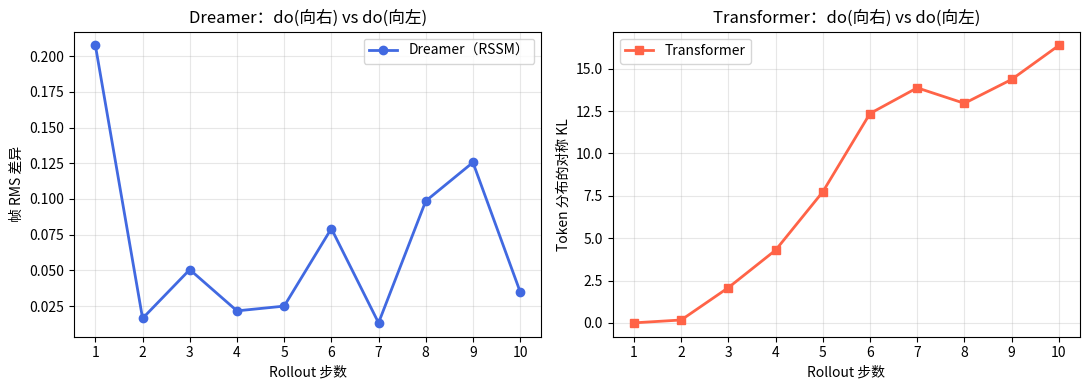

In [6]:
def frame_divergence(frames_a, frames_b):
    return [(fa - fb).pow(2).mean().sqrt().item() for fa, fb in zip(frames_a, frames_b)]


def token_kl_divergence(probs_a, probs_b, eps=1e-8):
    """计算两组逐步离散 token 分布之间的对称 KL 散度。"""
    pa = probs_a.clamp_min(eps)
    pb = probs_b.clamp_min(eps)
    kl = (pa * (pa / pb).log()).sum(-1) + (pb * (pb / pa).log()).sum(-1)
    return kl.cpu().tolist()


d_div = frame_divergence(d_frm_r, d_frm_l)       # Dreamer：像素 RMS
t_div = token_kl_divergence(t_prob_r, t_prob_l)  # Transformer：token KL
steps = list(range(1, ROLLOUT_LEN + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(steps, d_div, 'o-', color='royalblue', linewidth=2, label='Dreamer（RSSM）')
ax1.set_xlabel('Rollout 步数')
ax1.set_ylabel('帧 RMS 差异')
ax1.set_title('Dreamer：do(向右) vs do(向左)')
ax1.set_xticks(steps)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(steps, t_div, 's-', color='tomato', linewidth=2, label='Transformer')
ax2.set_xlabel('Rollout 步数')
ax2.set_ylabel('Token 分布的对称 KL')
ax2.set_title('Transformer：do(向右) vs do(向左)')
ax2.set_xticks(steps)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 第三层：通过溯因进行反事实 Rollout

干预式测试从一个空白潜在状态开始。反事实问题更强：拿一条*真实发生过*的轨迹，问在某个时间步上，如果智能体当时选择了另一种动作，而世界的其他部分都保持不变，会发生什么。Pearl 的配方有三个动作：先溯因，再施加动作，最后做预测。

溯因要做的是推断出真正产生这条观测轨迹的潜在状态。RSSM 的后验恰好在做这件事，因此我们把真实帧和真实动作一直送到某个分叉点。动作步骤是在这个分叉点用另一个选择替代真实动作。预测步骤则是从溯因得到的状态出发，在新动作下把先验向前 rollout。事实分支和反事实分支共享完全相同的过去，只在被干预的动作上不同，因此这个比较才是干净的反事实比较。

In [7]:
@torch.no_grad()
def abduct_state(obs_seq, act_seq, branch_t):
    """沿着真实轨迹运行 RSSM 后验直到 branch_t，返回 (h, s)。"""
    h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
    mu0, _ = encoder(obs_seq[0:1].to(DEVICE))
    s = mu0
    for t in range(branch_t):
        mu_t, _ = encoder(obs_seq[t:t+1].to(DEVICE))
        a_t = act_seq[t:t+1].to(DEVICE)
        s, h = rssm.posterior_step(h, a_t, mu_t)
    return h, s


@torch.no_grad()
def counterfactual_branch(h, action_seq):
    """从溯因得到的状态出发，在指定动作序列下预测先验 rollout。"""
    frames = []
    for a in action_seq:
        a_t = torch.tensor([a], device=DEVICE)
        s, h = rssm.prior_step(h, a_t)
        frames.append(decoder(torch.cat([h, s], dim=-1)).squeeze(0))
    return torch.stack(frames)


traj_i, BRANCH = 0, 4
obs_seq = eval_obs[traj_i]
act_seq = eval_act[traj_i]

h_b, s_b = abduct_state(obs_seq, act_seq, BRANCH)            # 溯因
factual_actions = act_seq[BRANCH:ROLLOUT_LEN].tolist()       # 真实发生的后续动作
cf_actions      = [1 - a for a in factual_actions]           # 翻转后的反事实动作

factual_frames = counterfactual_branch(h_b, factual_actions)
cf_frames      = counterfactual_branch(h_b, cf_actions)

print(f'已在第 {BRANCH} 步完成状态溯因，并向前 rollout 事实分支与反事实分支。')

已在第 4 步完成状态溯因，并向前 rollout 事实分支与反事实分支。


两条分支 rollout 完成后，将它们并排展示。共享前缀按构造方式本来就完全一致，因此后续任何可见差异，都是翻转动作带来的因果效应。

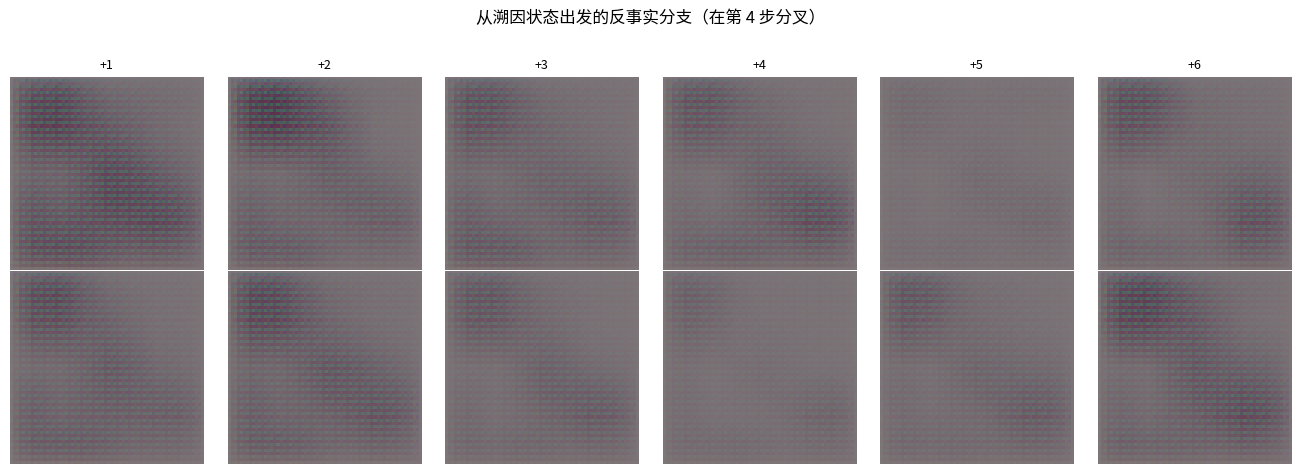

In [8]:
n_show = len(factual_actions)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.6))
for col in range(n_show):
    axes[0, col].imshow(np.clip(factual_frames[col].cpu().permute(1, 2, 0).numpy(), 0, 1))
    axes[1, col].imshow(np.clip(cf_frames[col].cpu().permute(1, 2, 0).numpy(), 0, 1))
    for row in range(2):
        axes[row, col].axis('off')
    axes[0, col].set_title(f'+{col + 1}', fontsize=9)
axes[0, 0].set_ylabel('事实分支', fontsize=10)
axes[1, 0].set_ylabel('反事实分支', fontsize=10)
fig.suptitle(f'从溯因状态出发的反事实分支（在第 {BRANCH} 步分叉）', y=1.02)
plt.tight_layout()
plt.show()

## 6. 让模型真正具有动作因果性

上面的 rollout 检查的是为预测而训练的模型，而不是为因果忠实性而训练的模型，所以一个模型即使重构分数很好，也可能在暗中忽略动作。World-Action Model 这一路工作通过逆动力学正则项来修正这一点：除了前向预测损失之外，再加一个小头，要求它从 `s_t` 到 `s_{t+1}` 的潜在转移中恢复出动作 `a_t`。如果无法从这段转移中读回动作，就说明动力学并没有真正以动作为条件。加入这个损失后，潜在状态转移就被迫携带动作带来的影响。

我们在这个合成环境上训练两个紧凑世界模型，一个带逆动力学项，一个不带，然后比较它们最终会对动作变得多敏感。

In [9]:
def make_training_set(n_traj=300, horizon=SEQ_LEN, base_seed=0):
    obs_list, act_list = [], []
    for i in range(n_traj):
        env = SyntheticEnv(seed=base_seed + i)
        obs = env.reset()
        traj_obs, traj_act = [obs], []
        rng = np.random.RandomState(base_seed + i + 50000)
        for _ in range(horizon):
            a = rng.randint(0, N_ACTIONS)
            nxt, _, _ = env.step(a)
            traj_act.append(a)
            traj_obs.append(nxt)
        obs_list.append(traj_obs[:horizon])
        act_list.append(traj_act)
    return (torch.tensor(np.array(obs_list), dtype=torch.float32),
            torch.tensor(np.array(act_list), dtype=torch.long))


class CompactWM(nn.Module):
    """带逆动力学头的小型动作条件潜在动力学模型。"""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, n_actions=N_ACTIONS):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Flatten(), nn.Linear(256 * 4 * 4, latent_dim),
        )
        self.a_embed = nn.Embedding(n_actions, latent_dim)
        self.fwd = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        # 逆动力学头：根据 (s_t, s_{t+1}) 恢复动作。
        self.inv = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def encode(self, x):
        return self.enc(x)

    def forward_dynamics(self, s, a):
        return self.fwd(torch.cat([s, self.a_embed(a)], dim=-1))

    def inverse_dynamics(self, s, s_next):
        return self.inv(torch.cat([s, s_next], dim=-1))


def train_compact_wm(use_inverse, epochs=8, lam=1.0, seed=0):
    torch.manual_seed(seed)
    model = CompactWM().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    obs, act = make_training_set()
    N, T = act.shape
    for _ in range(epochs):
        perm = torch.randperm(N)
        for i in range(0, N, 32):
            idx = perm[i:i + 32]
            o = obs[idx].to(DEVICE)                       # (B, T, 3, 64, 64)
            a = act[idx].to(DEVICE)                       # (B, T)
            B = o.shape[0]
            s = model.encode(o.reshape(B * T, 3, 64, 64)).reshape(B, T, -1)
            s_t, s_next = s[:, :-1], s[:, 1:]
            a_t = a[:, :-1]
            pred_next = model.forward_dynamics(s_t.reshape(-1, LATENT_DIM), a_t.reshape(-1))
            fwd_loss = F.mse_loss(pred_next, s_next.reshape(-1, LATENT_DIM).detach())
            loss = fwd_loss
            if use_inverse:
                a_logits = model.inverse_dynamics(s_t.reshape(-1, LATENT_DIM), s_next.reshape(-1, LATENT_DIM))
                loss = loss + lam * F.cross_entropy(a_logits, a_t.reshape(-1))
            opt.zero_grad()
            loss.backward()
            opt.step()
    model.eval()
    return model


print('正在训练带动作正则化的世界模型...')
causal_wm   = train_compact_wm(use_inverse=True)
print('正在训练基线世界模型（不含逆动力学项）...')
baseline_wm = train_compact_wm(use_inverse=False)
print('两个紧凑模型均已训练完成。')

正在训练带动作正则化的世界模型...
正在训练基线世界模型（不含逆动力学项）...
两个紧凑模型均已训练完成。


## 7. 动作影响度量

为了把动作条件性变成一个数字，我们测量：在留出状态上，只翻转动作而保持其他条件不变时，预测的下一个潜在状态会改变多少，并对这些状态求平均。尊重动作的模型会得到较大的 influence score；动作塌缩的模型则会得到接近零的分数。这里我们分别汇报带动作正则化的模型、基线模型，以及加载得到的 Dreamer RSSM。

动作影响度量（越高表示越依赖动作）:
  动作正则化世界模型 : 4.2859
  基线世界模型       : 1.6975
  Dreamer RSSM (P03) : 1.9550


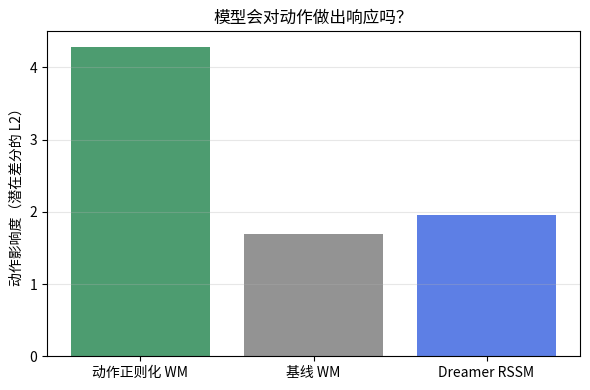

In [10]:
@torch.no_grad()
def action_influence_compact(model, obs, n=256):
    s = model.encode(obs[:n].to(DEVICE))
    a0 = torch.zeros(s.shape[0], dtype=torch.long, device=DEVICE)
    a1 = torch.ones_like(a0)
    s0 = model.forward_dynamics(s, a0)
    s1 = model.forward_dynamics(s, a1)
    return (s0 - s1).pow(2).sum(-1).sqrt().mean().item()


@torch.no_grad()
def action_influence_rssm(obs, n=256):
    h = torch.zeros(min(n, obs.shape[0]), rssm.hidden_dim, device=DEVICE)
    a0 = torch.zeros(h.shape[0], dtype=torch.long, device=DEVICE)
    a1 = torch.ones_like(a0)
    _, h0 = rssm.prior_step(h, a0)
    _, h1 = rssm.prior_step(h, a1)
    return (h0 - h1).pow(2).sum(-1).sqrt().mean().item()


flat_obs = eval_obs.reshape(-1, 3, 64, 64)
infl_causal   = action_influence_compact(causal_wm, flat_obs)
infl_baseline = action_influence_compact(baseline_wm, flat_obs)
infl_rssm     = action_influence_rssm(flat_obs)

print('动作影响度量（越高表示越依赖动作）:')
print(f'  动作正则化世界模型 : {infl_causal:.4f}')
print(f'  基线世界模型       : {infl_baseline:.4f}')
print(f'  Dreamer RSSM (P03) : {infl_rssm:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['动作正则化 WM', '基线 WM', 'Dreamer RSSM']
vals  = [infl_causal, infl_baseline, infl_rssm]
ax.bar(names, vals, color=['seagreen', 'gray', 'royalblue'], alpha=0.85)
ax.set_ylabel('动作影响度（潜在差分的 L2）')
ax.set_title('模型会对动作做出响应吗？')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

上面的标量只是一阶摘要。为了看见效应如何累积，我们让带动作正则化的模型和基线模型都从同一个编码状态出发，在 `do(向右)` 与 `do(向左)` 下分别向前 rollout，并绘制每一步预测潜在状态之间的分离程度。正则化模型应该会逐步张开，而基线模型会保持扁平，从而给出加载 checkpoint 时那些模型没有展示出来的清晰对比。

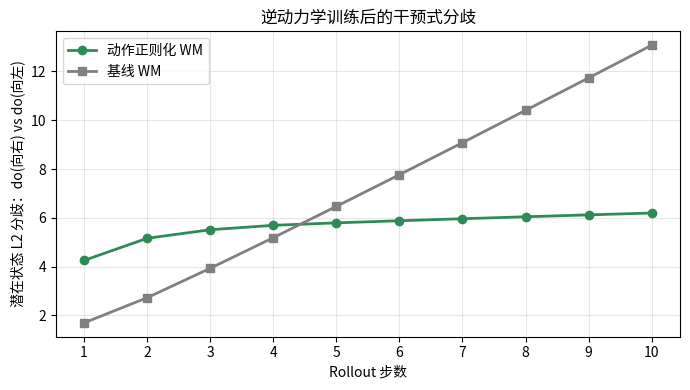

In [11]:
@torch.no_grad()
def compact_intervention_divergence(model, seed_obs, steps=ROLLOUT_LEN):
    """从同一个编码状态出发，比对 CompactWM 在 do(向右) 与 do(向左) 下的 rollout 分歧。"""
    s = model.encode(seed_obs.unsqueeze(0).to(DEVICE))
    s_r = s_l = s
    div = []
    for _ in range(steps):
        a_r = torch.zeros(1, dtype=torch.long, device=DEVICE)
        a_l = torch.ones(1, dtype=torch.long, device=DEVICE)
        s_r = model.forward_dynamics(s_r, a_r)
        s_l = model.forward_dynamics(s_l, a_l)
        div.append((s_r - s_l).pow(2).sum(-1).sqrt().item())
    return div


causal_div   = compact_intervention_divergence(causal_wm, seed)
baseline_div = compact_intervention_divergence(baseline_wm, seed)
steps = list(range(1, ROLLOUT_LEN + 1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, causal_div, 'o-', color='seagreen', linewidth=2, label='动作正则化 WM')
ax.plot(steps, baseline_div, 's-', color='gray', linewidth=2, label='基线 WM')
ax.set_xlabel('Rollout 步数')
ax.set_ylabel('潜在状态 L2 分歧：do(向右) vs do(向左)')
ax.set_title('逆动力学训练后的干预式分歧')
ax.set_xticks(steps)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 保存 Checkpoint 与总结

保存带动作正则化的模型，记录最关键的结果数字。

In [12]:
torch.save({
    'causal_wm': causal_wm.state_dict(),
    'action_influence': {
        'causal': infl_causal,
        'baseline': infl_baseline,
        'dreamer_rssm': infl_rssm,
    },
}, CAUSAL_CKPT)
print(f'已将动作正则化世界模型保存到 {CAUSAL_CKPT}')

print('\n--- P06 总结 ---')
print(f'  Dreamer / Transformer checkpoint 是否加载 : {dreamer_loaded} / {trans_loaded}')
print(f'  Dreamer 干预式分歧（第 10 步，RMS 像素） : {d_div[-1]:.4f}')
print(f'  Transformer 干预式分歧（第 10 步，token KL） : {t_div[-1]:.4f}')
print(f'  动作影响度（正则化模型）                : {infl_causal:.4f}')
print(f'  动作影响度（基线模型）                  : {infl_baseline:.4f}')
print('  二者之间存在明显差距，说明逆动力学项确实诱导出了动作条件性。')

已将动作正则化世界模型保存到 causal_wm.pt

--- P06 总结 ---
  Dreamer / Transformer checkpoint 是否加载 : True / True
  Dreamer 干预式分歧（第 10 步，RMS 像素） : 0.0350
  Transformer 干预式分歧（第 10 步，token KL） : 16.3754
  动作影响度（正则化模型）                : 4.2859
  动作影响度（基线模型）                  : 1.6975
  二者之间存在明显差距，说明逆动力学项确实诱导出了动作条件性。


P06 的核心结论是：准确率与因果忠实性是两条不同的坐标轴。一个世界模型可以很好地重构帧，这正是 P05 测量的问题，但它依然可能没有把动作的影响编码进去，而这正是这里测量的问题。反事实 rollout 会直接暴露这个缺口，而逆动力学正则项则提供了一种具体的补救方式。这也解释了为什么访谈里强调“结构化压缩”这个框架：有用的世界模型，压缩出来的应该是会对干预做出响应的变量，而不只是能够复现训练分布的统计量。